In [290]:
# Importing necessary libraries for data manipulation and visualization
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold

In [291]:
np.random.seed(0) # We need to generate same random numbers every time we run the code, so that we can compare our results with the expected results.

In [292]:
# Dogs: Lower whisker length, higher ear flappiness index
dogs_whisker_length = np.random.normal(loc = 5, scale = 1, size = 10)
dogs_ear_flappiness_index = np.random.normal(loc = 8, scale = 1, size = 10)

In [293]:
# Cats: Higher whisker length, lower ear flappiness index
cats_whisker_length = np.random.normal(loc = 8, scale = 1, size = 10)
cats_ear_flappiness_index = np.random.normal(loc = 5, scale = 1, size = 10)

In [294]:
print(dogs_whisker_length)
print(dogs_ear_flappiness_index)
print(cats_whisker_length)
print(cats_ear_flappiness_index)

[6.76405235 5.40015721 5.97873798 7.2408932  6.86755799 4.02272212
 5.95008842 4.84864279 4.89678115 5.4105985 ]
[8.14404357 9.45427351 8.76103773 8.12167502 8.44386323 8.33367433
 9.49407907 7.79484174 8.3130677  7.14590426]
[ 5.44701018  8.6536186   8.8644362   7.25783498 10.26975462  6.54563433
  8.04575852  7.81281615  9.53277921  9.46935877]
[5.15494743 5.37816252 4.11221425 3.01920353 4.65208785 5.15634897
 6.23029068 6.20237985 4.61267318 4.69769725]


In [295]:
# Linear Classifier
# d = Number of features (2 in our case - whisker length and ear flappiness index)
# k = Number of random linear classifiers we want to generate
def linear_classifier(data_dogs, data_cats, k, d):
    best_error = float('inf')
    best_theta = None
    best_theta0 = None

    for _ in range(k):
        theta = np.random.normal(0, 1, d)
        theta0 = np.random.normal(0, 1)

        error = compute_error(data_dogs, data_cats, theta, theta0)

        if error < best_error:
            best_error = error
            best_theta = theta
            best_theta0 = theta0

    return best_theta, best_theta0, best_error

def compute_error(data_dogs, data_cats, theta, theta0):
    error = 0

    for x_dog in data_dogs:
        if np.dot(theta, x_dog) + theta0 <= 0:
            error += 1

    for x_cat in data_cats:
        if np.dot(theta, x_cat) + theta0 > 0:
            error += 1

    return error

In [296]:
dogs_data = np.vstack((dogs_whisker_length, dogs_ear_flappiness_index)).T
cats_data = np.vstack((cats_whisker_length, cats_ear_flappiness_index)).T
data = np.vstack((dogs_data, cats_data))
labels = np.hstack((np.zeros(len(dogs_data)), np.ones(len(cats_data))))

In [297]:
X_train, X_test, Y_train, Y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

In [298]:
print("Dogs Data:\n", dogs_data)
print("Cats Data:\n", cats_data)
print("Training Data of X:\n", X_train)
print("Training Data of y:\n", Y_train)
print("Testing Data of X:\n", X_test)
print("Testing Data of y:\n", Y_test)

Dogs Data:
 [[6.76405235 8.14404357]
 [5.40015721 9.45427351]
 [5.97873798 8.76103773]
 [7.2408932  8.12167502]
 [6.86755799 8.44386323]
 [4.02272212 8.33367433]
 [5.95008842 9.49407907]
 [4.84864279 7.79484174]
 [4.89678115 8.3130677 ]
 [5.4105985  7.14590426]]
Cats Data:
 [[ 5.44701018  5.15494743]
 [ 8.6536186   5.37816252]
 [ 8.8644362   4.11221425]
 [ 7.25783498  3.01920353]
 [10.26975462  4.65208785]
 [ 6.54563433  5.15634897]
 [ 8.04575852  6.23029068]
 [ 7.81281615  6.20237985]
 [ 9.53277921  4.61267318]
 [ 9.46935877  4.69769725]]
Training Data of X:
 [[ 4.89678115  8.3130677 ]
 [ 4.02272212  8.33367433]
 [ 8.6536186   5.37816252]
 [ 7.2408932   8.12167502]
 [ 9.53277921  4.61267318]
 [ 8.04575852  6.23029068]
 [ 7.25783498  3.01920353]
 [ 5.97873798  8.76103773]
 [ 5.4105985   7.14590426]
 [ 9.46935877  4.69769725]
 [ 6.86755799  8.44386323]
 [ 8.8644362   4.11221425]
 [ 4.84864279  7.79484174]
 [ 5.44701018  5.15494743]
 [10.26975462  4.65208785]
 [ 5.95008842  9.49407907]]


In [299]:
# Define function for K-fold cross validation
def cross_validate(data, labels, k_values, d, n_splits = 5):
    kf = KFold(n_splits = n_splits, shuffle = True, random_state = 42)
    avg_errors = []

    for k in k_values:
        errors = []
        for train_index, val_index in kf.split(data):
            X_train_fold = data[train_index]
            Y_train_fold = labels[train_index]
            X_val_fold = data[val_index]
            Y_val_fold = labels[val_index]

            best_theta_fold, best_theta0_fold, error = linear_classifier(X_train_fold[Y_train_fold == 0], X_train_fold[Y_train_fold == 1], k, d)
            errors.append(compute_error(X_val_fold[Y_val_fold == 0], X_val_fold[Y_val_fold == 1], best_theta_fold, best_theta0_fold))

        avg_errors.append(np.mean(errors))
    best_k = k_values[np.argmin(avg_errors)]

    return best_k

# Define k values to try
k_values = [1, 10, 50, 100, 200, 350]
best_k = cross_validate(data, labels, k_values, d = 2)
print(f"Best k value: {best_k}")


Best k value: 200


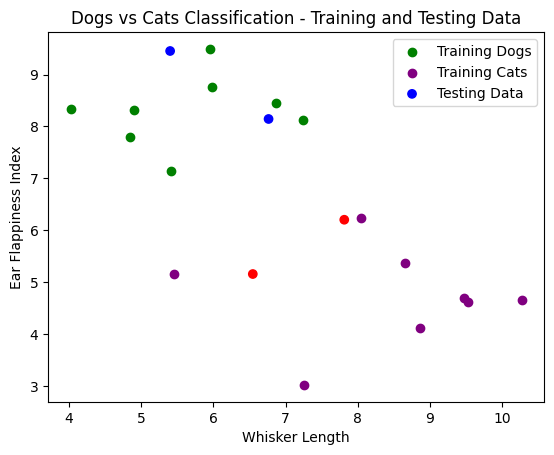

In [300]:
plt.scatter(X_train[Y_train == 0] [:, 0], X_train[Y_train == 0] [:, 1], color = 'green', label = 'Training Dogs')
plt.scatter(X_train[Y_train == 1] [:, 0], X_train[Y_train == 1] [:, 1], color = 'purple', label = 'Training Cats')
# c stands for color. So, use Y_test values to decide the color of each point
plt.scatter(X_test[:, 0], X_test[:, 1], c = Y_test, cmap = 'bwr', label = 'Testing Data') 
plt.xlabel('Whisker Length')
plt.ylabel('Ear Flappiness Index')
plt.title('Dogs vs Cats Classification - Training and Testing Data')
plt.legend()
plt.show()

In [301]:
k = best_k
d = 2
best_theta, best_theta0, error = linear_classifier(X_train[Y_train == 0], X_train[Y_train == 1], k, d)
print("Best Theta:", best_theta)
print("Best Theta0:", best_theta0)
print("Best Error:", error)

Best Theta: [-0.34180117  0.43761861]
Best Theta0: -0.8193335295358799
Best Error: 0


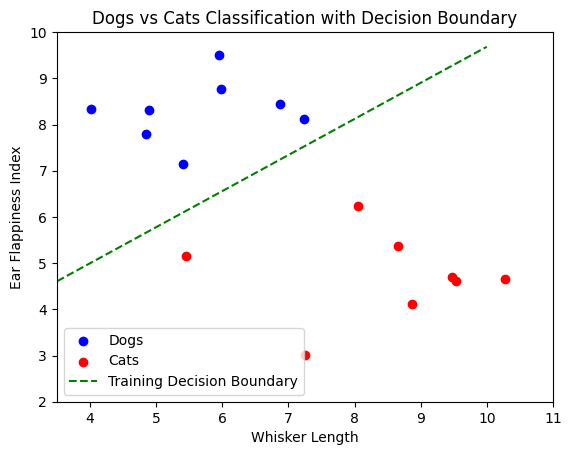

In [302]:
# Plot the decision boundary
x_values = np.linspace(2, 10, 100)
y_values = -(best_theta[0] * x_values + best_theta0) / best_theta[1]
plt.scatter(X_train[Y_train == 0][:, 0], X_train[Y_train == 0][:, 1], color = 'blue', label = 'Dogs')
plt.scatter(X_train[Y_train == 1][:, 0], X_train[Y_train == 1][:, 1], color = 'red', label = 'Cats')
plt.plot(x_values, y_values, color = 'green', linestyle = '--', label = 'Training Decision Boundary')
plt.xlim([3.5, 11])
plt.ylim([2, 10])
plt.xlabel('Whisker Length')
plt.ylabel('Ear Flappiness Index')
plt.title('Dogs vs Cats Classification with Decision Boundary')
plt.legend()
plt.show()

In [303]:
# Compute the training error
training_error = compute_error(X_train[Y_train == 0], X_train[Y_train == 1], best_theta, best_theta0)
print("Training Error:", training_error)

Training Error: 0


In [304]:
# Compute the test error
test_error = compute_error(X_test[Y_test == 0], X_test[Y_test == 1], best_theta, best_theta0)
print("Test Error:", test_error)

Test Error: 0


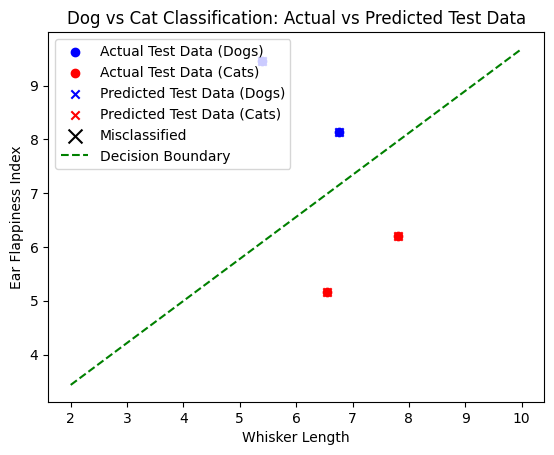

In [305]:
# Plot the actual test data and predicted test data
plt.scatter(X_test[Y_test == 0][:, 0], X_test[Y_test == 0][:, 1], c = 'blue', label = 'Actual Test Data (Dogs)')
plt.scatter(X_test[Y_test == 1][:, 0], X_test[Y_test == 1][:, 1], c = 'red', label = 'Actual Test Data (Cats)')

# Predict the test data using the decision boundary
predicted_labels = np.ones_like(Y_test)
for i, x in enumerate(X_test):
    if np.dot(best_theta, x) + best_theta0 > 0:
        predicted_labels[i] = 0

# Plot predicted test data points
plt.scatter(X_test[predicted_labels == 0][:, 0], X_test[predicted_labels == 0][:, 1], c = 'blue', marker = 'x', label = 'Predicted Test Data (Dogs)')
plt.scatter(X_test[predicted_labels == 1][:, 0], X_test[predicted_labels == 1][:, 1], c = 'red', marker = 'x', label = 'Predicted Test Data (Cats)')

misclassified = Y_test != predicted_labels

plt.scatter(X_test[misclassified][:,0], X_test[misclassified][:,1], color='black', marker='x', s=100, label='Misclassified')

# Plot the decision boundary
plt.plot(x_values, y_values, color = 'green', linestyle = '--', label = 'Decision Boundary')
plt.xlabel('Whisker Length')
plt.ylabel('Ear Flappiness Index')
plt.title('Dog vs Cat Classification: Actual vs Predicted Test Data')
plt.legend()
plt.show()